## CS5250 Final — Quantum Coin Flip (Qiskit)

In [1]:
from qiskit import QuantumCircuit, transpile

from qiskit_aer import AerSimulator


def circuit_to_ascii_diagram(circuit):
    try:
        return str(circuit.draw(output="text", use_unicode=False, fold=-1))
    except TypeError:
        return str(circuit.draw(output="text", fold=-1))


def run_on_simulator(circuit, *, shots=2048, seed=123):
    # Create the simulator backend.
    backend = AerSimulator(seed_simulator=seed)

    compiled = transpile(circuit, backend)

    job = backend.run(compiled, shots=shots)

    result = job.result()

    return dict(result.get_counts())


## Build the circuit

### Circuit structure
- **1 qubit** (`q0`)
- **1 classical bit** (`c0`)

### Steps
1. Apply **H** to create superposition
2. Measure the qubit into the classical bit

In [2]:
def build_coin_flip_circuit():

    qc = QuantumCircuit(1, 1, name="coin_flip")

    # qc.h(0) applies the Hadamard gate to qubit 0.
    qc.h(0)

    # qc.measure(0, 0) measures qubit 0 and stores the result into classical bit 0.
    qc.measure(0, 0)

    return qc


# Build the circuit now.
coin = build_coin_flip_circuit()

print(circuit_to_ascii_diagram(coin))


     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


In [ ]:
shots = 2048

seed = 123

coin_counts = run_on_simulator(coin, shots=shots, seed=seed)

coin_counts

{'1': 1031, '0': 1017}

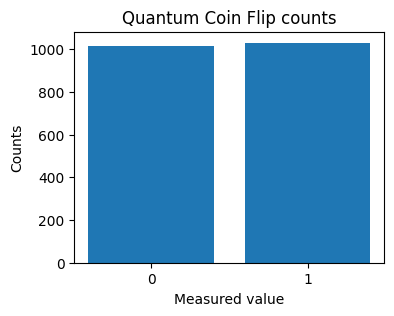

In [4]:
import matplotlib.pyplot as plt

keys = sorted(coin_counts.keys())

values = [coin_counts[k] for k in keys]

plt.figure(figsize=(4, 3))

plt.bar(keys, values)

plt.title("Quantum Coin Flip counts")
plt.xlabel("Measured value")
plt.ylabel("Counts")

# Display the plot.
plt.show()
